# Capstone Project

## Imports

In [88]:
import os
import itertools
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
import igraph as ig
import leidenalg as la
import random
from sklearn.metrics import jaccard_score
from tabulate import tabulate
from IPython.display import HTML, display
import html
import time
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
import numpy as np
from collections import Counter
import pickle
import math

In [2]:
random.seed(39)

In [3]:
with open("oracle-cards-20260508090243.json", "r", encoding="utf-8") as file:
    FullCardList = json.load(file)

# remove add duplicates explained below ======================================================================
before = len(FullCardList)
print("Total Before Removal: ", before)

itemsRemoved = {}

for c in FullCardList[:]: # copy so we can delete and iterate at same time
    if "//" in c["name"]:
        parts=c["name"].split("//")
        if parts[0].strip() == parts[1].strip():
            itemsRemoved[c["name"]] = c.items()
            FullCardList.remove(c)

print("number of items removed (//): ", len(itemsRemoved))
print("")
print("Total after removal: ", len(FullCardList))
print("Total number of items removed: ", before - (len(FullCardList)))

removeElements = ["set_type",
                  "mtgo_id",
                  "tcgplayer_id",
                  "lang",
                  "released_at",
                  "uri",
                  "scryfall_uri",
                  "highres_image",
                  "image_status",
                  "image_uris",
                  "set_uri",
                  "set_search_uri",
                  "scryfall_set_uri",
                  "rulings_uri",
                  "prints_search_uri",
                  "watermark",
                  "artist",
                  "artist_ids",
                  "illustration_id",
                  "border_color",
                  "frame",
                  "frame_effects",
                  "security_stamp",
                  "full_art",
                  "testless",
                  "booster",
                  "story_spotlight",
                  "related_uris",
                  "purchase_uris",
                  "digital",
                  "foil",
                  "nonfoil",
                  "preview",
                  "games",
                  "finishes",
                  "oversized",
                  "promo",
                  "reprint",
                  "textless"]

for card in FullCardList:
    for key in removeElements:
        card.pop(key,None)

cardsInfo = {card["name"]: card for card in FullCardList}

Total Before Removal:  37442
number of items removed (//):  2189

Total after removal:  35250
Total number of items removed:  2192


## Funcitons

In [4]:
#
# read the text files
# get out the deck list a set of unqinue cards
# and add the cards to the complete snapshot set
#
def readFiletxt(file, cardSet):

    decklist = set()
    
    with open(file, "r", encoding="cp1252") as f:
        for line in f:
            
            if(line.strip() == "Sideboard"):
                break
            else:
                parts = line.split(" ",1)
                #print(parts[1])
                if ( checkLands(parts[1].strip()) ):
                    continue

                else:
                    cardSet.add(parts[1].strip())
                    decklist.add(parts[1].strip())
        
    return decklist, cardSet


#
# read the mwDeck files
# get out the deck list a set of unqinue cards
# and add the cards to the complete snapshot set
#

def readFilemwDeck(file, cardSet):
    decklist = set()
    
    with open(file, "r", encoding="cp1252") as f:
        for line in f:
            #print(line)

            if line.startswith("//"):
                continue

            if line.startswith("SB:"):
                continue
            
            else:
                parts = line.split(" ",2)
                #print(parts[2].strip())
                if ( checkLands(parts[2].strip()) ):
                    continue

                else:
                    cardSet.add(parts[2].strip())
                    decklist.add(parts[2].strip())
        
    return decklist, cardSet

In [5]:
#
# using this method to check cards and see if they are lands
# land cards act as bridges to archtypes that share colour but they themselves dont carry much information,
# since they are required to be in decks they lead to archtypes being condensed together
#
#
def checkLands(checkCard):

    typeLineCheck = ""
    pCards = []

    if "/" in checkCard:
        parts=checkCard.split("/")
        checkCard=parts[0]
        

    # if the card name flat out exists in the dict save it
    if checkCard in cardsInfo:
            typeLineCheck = cardsInfo[checkCard]["type_line"]

    else: # esle try and search for similar
        for c in FullCardList:
            if checkCard.lower() in c["name"].lower():
                pCards.append(c["name"])

        # if only one similar save it
        if (len(pCards) == 1):
            typeLineCheck = cardsInfo[pCards[0]]["type_line"]
                
        
        else:
            #print("+++++++++++++++++++++++++++++++++++++++")
            #print("")
            #print("Error")
            #print("")
            #print(checkCard)
            #print("")
            #print(pCards)
            #print("")
            #print("+++++++++++++++++++++++++++++++++++++++")
            
            #if a card name appears multiple times high likelihood of not being a land
            return False


    if ("Land" in typeLineCheck) and ("//" not in typeLineCheck):
        return True

    else:
        return False
    

In [6]:
#
# this goes into my folders to grab the specific files
# based on file type it uses the correct file reader
# then it prints out the number of total cards and the number of decks
# number of decks used for normalisation
# number of unqiue cards is number of nodes for this snapshot
def getSnapshot(folder):

    snapshotSet = set()
    listOfDecks = []

    for itemMajor in os.listdir(folder):
        #print(itemMajor)
        newpath = os.path.join(folder, itemMajor)
        for itemMinor in os.listdir(newpath):
            #print(itemMinor)
            newestpath = os.path.join(newpath, itemMinor)

            if newestpath.endswith(".mwDeck"):
                temp, snapshotSet = readFilemwDeck(newestpath,snapshotSet)
                listOfDecks.append(temp)
                

            if newestpath.endswith(".txt"):
                temp, snapshotSet = readFiletxt(newestpath,snapshotSet)
                listOfDecks.append(temp)
                


    print("-- Statisitcs --")
    print("   Snapshot               :" , folder)
    print("   number of cards        :" , len(snapshotSet))
    print("   number of Decks        :" , len(listOfDecks))
    print("")
    return snapshotSet, listOfDecks
                
    

In [7]:
##
# use sorted tuples for dictionary to form weighted edge list
# take list of unique cards in each deck
# increase dicitonary value for each time a pair appears
# return this dictionary and a dictionary of each time a card appears
#

def makeEdgeList(decks):

    countPairs = {} #dicitonary of pairs of cards (SORT ALPHABETICALLY) count of pairs appearance
    countCards = {} #dict of cards appearance 

    for deck in decks:
        for card in deck:
            if card not in countCards:
                countCards[card] = 1

            else:
                countCards[card] += 1


        for pairs in itertools.combinations(deck,2):
            pairs = tuple(sorted(pairs))
            
            if pairs not in countPairs:
                countPairs[pairs] = 1

            else:
                countPairs[pairs] += 1

    return countCards, countPairs
    

In [8]:
#
#
# make graphs
# make an undirected weighted graph 
#
def makeUndirectedGraph(edges, noDecks):

    G = nx.Graph()
    for key in edges:

        G.add_edge(key[0],key[1],weight = edges[key]/noDecks) # edges are normalised by => pair appearances /total number of decks

    return G

#
# directed weighted graph
#
def makeDirectedGraph(edges, cards):

    G = nx.DiGraph()
    for key in edges:

        # (from_node , to_node) 
        # probablity of to_node, given from_node
        temp = edges[key]/ cards[key[0]]
        G.add_edge(key[0],key[1],weight=temp)

        temp = edges[key]/ cards[key[1]]
        G.add_edge(key[1],key[0],weight=temp)

    return G
    

In [9]:
##
# return a dict of communitities and items in those communities without the scores
#
#
def stripScores(toBeStriped):
    temp = []
    for x in toBeStriped:
        temp.append(x[0]) 
    return temp

### Graph Functions (Networks)

In [10]:
def drawGraph(G,p):

    plt.figure(figsize=(30,30))

    nodeColors="blue"

    pos = nx.spring_layout(G, k=1, iterations=10,seed=39)
    #pos = nx.kamada_kawai_layout(G)

    colourList = ["red",
                 "blue",
                 "green",
                 "skyblue",
                 "orange",
                 "yellow",
                 "purple",
                 "grey",
                 "lightgreen",
                 "pink",
                  "lime",
                  "cyan",
                  "coral",
                 ]

    nodeColors = [colourList[p[node]] for node in G.nodes()]
    
    nx.draw(
        G,
        pos,
        with_labels=False,
        node_size = 500,
        node_color = nodeColors
    )
    plt.show()
    

### Louvain Functions

In [11]:
# this is the default louvain run
#
def getlouvainPart(G, cards, r= True, seed = 39):

    outputDict = {}
    
    random.seed(seed)
    p = community_louvain.best_partition(G, randomize = r) #get louvian partition
    #print number of communtieis and paritions
    print("Number of communities : " , len(set(p.values()))) 
    tempScore = community_louvain.modularity(p, G)
    print("Modularity Score      : " ,  tempScore)
    print("")

    for i in set(p.values()):
        temp = []

        for node in p:
            if p[node] == i:
                temp.append((node, cards[node]))

        # print top 10 per community
        print("  ===== Communitiy ", i ," =====")

        sortedD = sorted(temp, key= lambda x: x[1], reverse=True)
        print(len(sortedD))
                
        if len(sortedD) > 10:
            x = 0
            while (x < 10):
                print(sortedD[x])
                x +=1

        if len(sortedD) <= 10:
            x = 0
            while (x < len(sortedD)):
                print(sortedD[x])
                x +=1

        outputDict["com" + str(i)] = sortedD
        print("")
        print("")
        print("")
    return p , outputDict


def getleidenPart(G, cards):
    return 0


    

In [12]:

#### consensus cluster Louvain
#
#
#
#

def makeUndirectedGraph2(edges, noDecks, all_nodes):

    G = nx.Graph()
    G.add_nodes_from(all_nodes)
    for key in edges:

        G.add_edge(key[0],key[1],weight = edges[key]/noDecks) # edges are normalised by => pair appearances /total number of decks

    return G


# main body of consensus
def getlouvain(G):
     return community_louvain.best_partition(G)
# function to call louvain and then take the partition and build up the adjacency matrix

def consensusLouvain(G, noTimes, threshold, iterations):
    going = True
    output = 0
    countIters = 0
    while(going):

        
        tempEL = {}
        #apply louv to G a number of times
        for n in range(noTimes):
            tempP = getlouvain(G)

            #build a matrix from this continuousley adding 
            for pairs in itertools.combinations(tempP.keys(),2):
                
                pairs = tuple(sorted(pairs))
                #if both nodes are in the same partition
                if tempP[pairs[0]] == tempP[pairs[1]]:
                    if pairs not in tempEL:
                        tempEL[pairs] = 1

                    else:
                        tempEL[pairs] += 1


        if (all(v==0 or v==noTimes for v in tempEL.values())):
            going = False

        tempEL = {pair: count for pair, count in tempEL.items() if count >= (threshold*noTimes)}
        G = makeUndirectedGraph2(tempEL, noTimes, G.nodes())

        
        
        output = getlouvain(G)

        
        if countIters > iterations - 1:
            going = False
        else:
            countIters += 1
            #print(countIters)

        

    finalpartition = output
    return finalpartition
    
    
#main body where all the usefull information is printed out post consensus
def getlouvainPart2(G, cards, numberOfTimes, threshold):
    #random.seed(seed)

    

    p = consensusLouvain(G, numberOfTimes, threshold, 10)


    # ========== finalised scores and communities ==========
    outputDict = {}
    print("Number of communities : " , len(set(p.values())))
    tempScore = community_louvain.modularity(p, G)
    print("Modularity Score      : " ,  tempScore)
    #print("")

    for i in set(p.values()):
        temp = []

        for node in p:
            if p[node] == i:
                temp.append((node, cards[node]))


        print("  ===== Communitiy ", i ," =====")

        sortedD = sorted(temp, key= lambda x: x[1], reverse=True)
        print(len(sortedD))
                
        if len(sortedD) > 10:
            x = 0
            while (x < 10):
                print(sortedD[x])
                x +=1

        if len(sortedD) <= 10:
            x = 0
            while (x < len(sortedD)):
                print(sortedD[x])
                x +=1

        outputDict["com" + str(i)] = sortedD
        print("")
        print("")
        print("")
    return p , outputDict, tempScore
    
    #so run louvain 100s of times
#store results in a matrix
#build a graph using said matrics with the edges between them being Aij / total runs

In [13]:
#
# due to the fluqtuations in the consensus Louvain algorithm I will run it 10 times for each snpashot and use the most commonly occuring graph 
# another way to counter randomness
#

def bestPart(G, cards, numberOfTimes, threshold, runs):

    # use NMI to determine if two paritions are the same
    determinePart = {}

    for ran in range(runs):
        p = consensusLouvain(G, numberOfTimes, threshold, 10)

        if len(determinePart) < 1:
            determinePart[ran] = {
                "Dict": p,
                "Appearances": 1
            }

        else:
            found = False
            for key, value in determinePart.items():
                

                nodes = sorted(value["Dict"].keys())
                compare1 = [value["Dict"][n] for n in nodes]
                compare2 = [p[n] for n in nodes]

                temporary = normalized_mutual_info_score(compare1, compare2)
            
                if temporary == 1:
                    determinePart[key] = {
                        "Dict": value["Dict"],
                        "Appearances": value["Appearances"] + 1
                    }
                    found = True
                
            if not found:
                determinePart[ran] = {
                "Dict": p,
                "Appearances": 1
                }
                
    bestpartOut = max(determinePart.items(), key=lambda x:x[1]["Appearances"])
    return bestpartOut[1]["Dict"], bestpartOut[1]["Appearances"]



def getlouvainPart3 (G, cards, numberOfTimes, threshold, runs):

    
        
    p, appearances = bestPart(G, cards, numberOfTimes, threshold, runs)


    # ========== finalised scores and communities ==========
    outputDict = {}
    print("Number of communities                : " , len(set(p.values())))
    tempScore = community_louvain.modularity(p, G)
    print("Modularity Score                     : " ,  tempScore)
    print("Number of Appearances from consensus : ",appearances )
    #print("")

    for i in set(p.values()):
        temp = []

        for node in p:
            if p[node] == i:
                temp.append((node, cards[node]))


        print("  ===== Communitiy ", i ," =====")

        sortedD = sorted(temp, key= lambda x: x[1], reverse=True)
        print(len(sortedD))
                
        if len(sortedD) > 10:
            x = 0
            while (x < 10):
                print(sortedD[x])
                x +=1

        if len(sortedD) <= 10:
            x = 0
            while (x < len(sortedD)):
                print(sortedD[x])
                x +=1

        outputDict["com" + str(i)] = sortedD
        print("")
        print("")
        print("")
    return p , outputDict, tempScore

### Graph statistics functions

In [14]:
def getPagerank(G, seePRNumber, coms):

    #get the pageranks for all cards
    p = nx.pagerank(G, weight="weight")
    pSorted = sorted(p.items(), key=lambda x: x[1], reverse=True)

    #print out the top 10
    print("             Top ",seePRNumber," cards by Page Rank Overall")
    x = 0
    while x < seePRNumber:
        print(pSorted[x])
        x +=1

    print("")
    print("")
    print("")


    #top 10 pageranks per communtiy
    
    for i in set(coms.values()):
        temp = []

        for node in coms:
            if coms[node] == i:
                temp.append((node, p[node]))
        print("  ===== Communitiy ", i ," =====")

        sortedD = sorted(temp, key= lambda x: x[1], reverse=True)
        print(len(sortedD))
                
        if len(sortedD) > 10:
            x = 0
            while (x < 10):
                print(sortedD[x])
                x +=1

        if len(sortedD) <= 10:
            x = 0
            while (x < len(sortedD)):
                print(sortedD[x])
                x +=1
                
        print("")
        print("")
        print("")
        
    return p

    

In [15]:
def densityPerCom(G, communityList):

    comsList = {}
    for x, y in communityList.items():
        comsList[x] = stripScores(y)

    print("Density per Community")
    for x, y in comsList.items():
    
        print(f"Community {x} had a Density of : ",nx.density(nx.subgraph(G,y)) )

    return 0

In [16]:

#
# print out the useful and main statistics of the graph
# prints out information based on graph type (directed/undirected)
#
def graphStats(G):

    # universal stats =========================================================
    noNodes = G.number_of_nodes()
    noEdges = G.number_of_edges()
    density = nx.density(G)

    print("number of Nodes                          : " , noNodes)
    print("number of Edges                          : " , noEdges)
    print("density (fraction of all possible nodes) : " , density)

    # undirected stats ===================================================
    if not nx.is_directed(G): #undirected 
        avgDegree = 0
        for node, deg in G.degree:
            avgDegree += deg

        avgDegree = avgDegree/noNodes
        print("Average degree                           : ", avgDegree)

        
        avgEdgeW = 0
        temp = G.edges(data=True)
        for n in temp:
            avgEdgeW += n[2]["weight"]

        avgEdgeW = avgEdgeW/noEdges
        print("Average Edge Weight                      : ", avgEdgeW)

        


    #directed stats===========================================
    else:
        avgInDegree = 0
        for node, value in G.in_degree():
            avgInDegree += value

        avgInDegree = avgInDegree/noNodes
        print("Average In degree                         : ", avgInDegree)
        
        avgOutDegree = 0
        for node, value in G.out_degree():
            avgOutDegree += value

        avgOutDegree = avgOutDegree/noNodes
        print("Average Out degree                        : ", avgOutDegree)
    

    #number of connected components
    
    print("")
    print("")
    return noNodes
    

### Main body function

In [17]:
def snapToGraph(pathway, cardSetSoFar,numberLouvain,  threshold, runs ):

    cardsInSnap = set()

    #parse the snapshot and get a set of all the cards
    # and a list of sets of all the decks
    # i.e each deck but only the unique cards in said deck
    cardset, decks = getSnapshot(pathway)

    #get card occurances
    #get pairwise occurances
    cardsOcc, pairsOcc = makeEdgeList(decks)


    #return the updated cards set
    cardSetSoFar.update(cardset) # this is so we have a set which can be built upon and will contain all cards period
    cardsInSnap.update(cardset) # this is so we have a set of exclusively this snapshot
    #print("length : ", len(decks))
    print("# cards that have appeared so far :", len(cardSetSoFar))

    graph = makeUndirectedGraph(pairsOcc, len(decks) )
    digraph = makeDirectedGraph(pairsOcc, cardsOcc)

    
    print("Number of times louvain is ran per iteration: ", numberLouvain)
    print("Threshold: ", threshold)
    print("")
    print("------------- Undirected Graph Stats -------------")
    graphStats(graph)
    comms, commsDict, modularity = getlouvainPart3(graph, cardsOcc, numberLouvain, threshold, runs)


    print("")
    print("------------- Directed Graph Stats -------------")
    graphStats(digraph)

    cardsPageRank = getPagerank(digraph, 10, comms)

    
    cardsOccNorm = cardsOcc.copy()
    for name,x in cardsOccNorm.items():
        cardsOccNorm[name]= x /len(decks)


    print("== ==")
    densityPerCom(graph, commsDict)

    # graph
    # digraph = directed graph
    # cardSetSoFar =  continuous set of cards that will be added to with each subsequent snapshot
    # cardsOcc = dictionary of cards and that cards number of occurances
    # commsDict = dictionary of communities
    # cardsInSnap = set of cards in this specific snapshot
    # cardsPageRank = dict of cards in this snpashot and thier pagerank
    # cardsOccNorm = dict of cards in this snpashot and thier occurance normalised
    return graph, digraph, cardSetSoFar, cardsOcc, commsDict, cardsInSnap, cardsPageRank, cardsOccNorm, modularity

### Comparison functions

In [18]:
# do jaccaard similairity
# set intersection over union
def jaccardSim(com1, com2, verbose):

    temp1 = []
    for x in com1:
        temp1.append(x[0])

    temp2 = []
    for x in com2:
        temp2.append(x[0])
    
    set1 = set(temp1)
    set2= set(temp2)
    
    top = len( (set1).intersection(set2) )
    bot = len( (set1).union(set2) )

    if(verbose):
        print(top)
        print(bot)
        print((set1).intersection(set2))
    return top/bot, top

In [19]:
def removeFromSet(RemoveFrom,beingRemoved):
    temp1 = []
    for x in beingRemoved:
        temp1.append(x[0]) # this is now a clean without scores

    return RemoveFrom - set(temp1)

def compareIntersect(comparison1, comparison2):
    temp1 = []
    for x in comparison2:
        temp1.append(x[0]) # this is now a clean without scores
    return len(comparison1.intersection(set(temp1)))
    

## Graphing functions (Temporal)

In [20]:
#
# graphing a specific card over time 
# uses either pagerank or normalised occurances
#
def graphOverTime(Cardname, stats):

    temp = []
    for x in stats:
        if Cardname in x:
            temp.append(x[Cardname])

        else:
            temp.append(None)

    plt.plot(range(1,len(temp)+1), temp, marker="o")
    plt.xticks(range(len(temp)+1))
    plt.show()
    return temp


def graphSnapshotsOverTime(scores,y_label):
    plt.plot(range(1,len(scores)+1), scores, marker="o")
    plt.xticks(range(len(scores)+1))
    plt.xlabel("Snapshot")
    plt.ylabel(y_label)
    plt.savefig(f"{y_label}.png", dpi=300, bbox_inches="tight")
    plt.show()
    return scores

### Reccomender Functions

In [21]:
##
# Reccomendation funcitons 
#
#

def readFileR(file):

    decklist = []
    
    with open(file, "r", encoding="cp1252") as f:
        for line in f:
            if(line.strip() == "Sideboard"):
                continue
            
            parts = line.split(" ",1)
            #print(parts[1])
            for x in range(int(parts[0].strip())):
                decklist.append(parts[1].strip())
        
    return decklist

#
# Return a list that reccomends top 10 based on weight of edges
#
def top10addition(G, decklist):
    reccomendations = {}

    # so we want to get the cards related to x
    for x in decklist:
        if (checkLands(x)):
            continue
        else:
            neighbours = list(G.neighbors(x))

            for y in neighbours:
                if y in decklist:
                    continue
                    
                weight = G[x][y]["weight"]
                #print(y , weight)

                if y in reccomendations:
                    reccomendations[y] += weight
                else:
                    reccomendations[y] = weight
                

    reccomendations = sorted(reccomendations.items(), key=lambda x: x[1], reverse= True)

    print("  ==== Reccomend Cards based on Edges ====")
    print("")
    for x in range(10):
        print(reccomendations[x][0])

    print("")
    print("")
            
    return reccomendations
    

##
# main body funciton to run all reccomendation methods
# takes decklist from a file
# suggests 10 reccomendations
#
def Reccomender(G, pathway):

    deck = readFileR(pathway)

    out1 = top10addition(G, deck)

    
    return 0





### Track cards across snapshots

In [22]:
def jaccardTable(i,j, snap1, cards1, snap2, cards2):
    #compare all of the two snapshots communities

    total = cards1.union(cards2) # every unique card in both snapshots
    finalCardTotal = 0
    
    tab = [] #this is what will be printed out using tabulate
    for name1,x in snap1.items():
        temp = []
        headings = [] # keep track of headings
        headings.append(str(i) + "\\" + str(j)) 
        headings.append("# in Community")
        temp.append(name1)
        temp.append(len(x))
        cardsAccountedFor = 0
        tempTotal = total.copy() # copy over so I can reuse
        
        for name2,y in snap2.items():
            
            tempTotal = removeFromSet(tempTotal,y) #converts dictionary with scores into a list
            headings.append(name2)
            out, add = jaccardSim(x, y, False) #print "out". sum "add" to make sure all cards are accounted for
            cardsAccountedFor += add # using this to account for all cards
            temp.append(out) 
            

        #adding outputs to finalised table 
        temp.append(cardsAccountedFor)
        tempintersect = compareIntersect(tempTotal, x)
        temp.append(tempintersect)
        finalCardTotal += cardsAccountedFor + tempintersect
        tab.append(temp)
    # and addtional styling 
    headings.append("Cards Accounted For")
    headings.append("Cards Unaccounted For")
    outputTable = tabulate(tab, headers=headings, tablefmt="grid")

    #code to make tables scrollable
    display(HTML(f"""
    </div style="overflow-x: auto; width:100%;">
    <pre style="white-space:pre; font-family:monospace;">{html.escape(outputTable)}</pre>
    
    </div>
    """))
    return finalCardTotal

In [23]:
def searchNewComs(commingFrom, goingTo, listOfCards, NewComs):
    # take the listOfCards 
    # search through the communities in NewComs
    # assuming listOfCards was the cards deemed to be most important of a particular community 
    # in the previous snapshot I can track adn see where they all ended up

    for x, y in enumerate(listOfCards):
        if isinstance(y,tuple):
            listOfCards[x] = y[0]
        
    print("")
    print("           Original Community's most important cards")
    print("")

    for k in range(len(listOfCards)):
        print(listOfCards[k])
    
    print("")
    print(f"          Going From Snapshot {commingFrom} into Snapshot {goingTo}")
    print("")
    print("")
    

    notAppearing = listOfCards.copy()
    notAppearing = set(notAppearing)
    
    for keys, c in NewComs.items():

        
        output = []
        
        temp = []
        for y in c:
            temp.append(y[0])

        #print(temp)
        for x in listOfCards:
            
           
            if x in temp:
                output.append(x)


        print(f"===  {keys} ===")
        for i in range(len(output)):
            print(output[i])
            #print(notAppearing)
            notAppearing.discard(output[i])

        print("")
        print("")


    if len(notAppearing) == 0:
        print(f"All cards survived and appeared in one of the communities")

    else:
        print(f" cards that did not appear in snapshot {goingTo}")
    
        for item in notAppearing:
            print(item)

        print("")
                


In [24]:
def whichComsIsDeckIn(listOfCards, coms):
    # take the listOfCards 
    # search through the communities
    # paste out which communtiies all cards are in

    temporary =set()
    if listOfCards.endswith(".mwDeck"):
        temp, _ = readFilemwDeck(listOfCards,temporary)
        
                

    if listOfCards.endswith(".txt"):
        temp, _ = readFiletxt(listOfCards,temporary)
        
                
    listOfCards = temp
    if type(listOfCards) is set:
        listOfCards = list(listOfCards)
        
    print("")
    print("      My Decklist        ")
    print("")

    for k in range(len(listOfCards)):
        print(listOfCards[k])


    print("")
    print("      Where do the cards end up        ")
    print("")

    
    for keys, c in coms.items():

        
        output = []
        
        temp = []
        for y in c:
            temp.append(y[0])

        #print(temp)
        for x in listOfCards:
            if x in temp:
                output.append(x)


        print(f"===  {keys} ===")
        for i in range(len(output)):
            print(output[i])
            

        print("")
        print("")

In [25]:

def identitySets(cards, cardInfoList):

    whichSets = {}
    for x in cards:
        temp = []

        for c in FullCardList:
            if x.lower() in c["name"].lower():
                 temp.append(c["name"])

        if len(temp) == 1:
            x = temp[0]

            if cardInfoList[x]["set_name"] in whichSets:
                whichSets[cardInfoList[x]["set_name"]] = whichSets[cardInfoList[x]["set_name"]] + 1

            else:
                whichSets[cardInfoList[x]["set_name"]] = 1

    
    whichSets = dict( sorted(whichSets.items(), key= lambda x: x[1], reverse=True) )
    for k,v in whichSets.items():
        print(k , " : ", v)

    return whichSets
    

# see where the majority of new crads landed when introduced / reintroduced (anything not in previous snapshot)
def newCardsLanding(cardsOldSnapshot, cardsNewSnapshot, communityList, cardInfoList):

    oldCards = cardsOldSnapshot.copy()
    newCards = cardsNewSnapshot.copy()

    onlyNewCards = newCards - oldCards

    print(len(onlyNewCards))

    #print(onlyNewCards)
    accounted = 0

    comsList = {}

    outputList = []

    for x, y in communityList.items():
        comsList[x] = stripScores(y)
        
    for keys,x in comsList.items():
        temp = []
        #print(x)
        for y in onlyNewCards:
            #print(y)
            if y in x:
                temp.append(y)
                accounted += 1

        outputList.append(temp)

    print(" ======== Where did New cards end up ======== ")
    print(f" = There where {len(onlyNewCards)} cards not in the preivous Snapshot = ")
    for count, x in enumerate(outputList):

        print(f" = Community {count} had {len(x)} cards that weren't from the previous snapshot")
        


    print("")
    print(" == which sets are cards that are not found in the previous snapshot comming from ==")
    print("")
    whichsets = identitySets(onlyNewCards, cardInfoList)
    

    return len(onlyNewCards) - accounted



### Comparison to labels pipeline

In [26]:
###
# here are the set of functions used to get the labels of the decks
# this is so we can compare the communities to human made labels
#
#----------------------
#
# use the filename to get the architype label
#
def getArchitype(deckpathway):
    # first strip down to file name
    filename = deckpathway.split("\\")
    filename = filename[-1]

    architype = ""
    
    notname = []
    parts = filename.split("_")
    for x in parts:
        if x == "by":
            for y in notname:
                architype = architype + y + " "
                
        else:
            notname.append(x)
            
    return architype.strip()

#
# alternative read functions for archtype analysis ------------------------------------------------
#
def readFiletxt2(file):

    decklist = []
    
    with open(file, "r", encoding="cp1252") as f:
        for line in f:
            
            if(line.strip() == "Sideboard"):
                break
            else:
                parts = line.split(" ",1)
                #print(parts[1])
                if ( checkLands(parts[1].strip()) ):
                    continue

                else:
                    for x in range(int(parts[0].strip())):
                        decklist.append(parts[1].strip())
        
    return decklist, getArchitype(file)


#
# alternative read functions for archtype analysis
#

def readFilemwDeck2(file):
    decklist = []
    
    with open(file, "r", encoding="cp1252") as f:
        for line in f:
            #print(line)

            if line.startswith("//"):
                continue

            if line.startswith("SB:"):
                continue
            
            else:
                parts = line.split(" ",2)
                #print(parts[2].strip())
                if ( checkLands(parts[2].strip()) ):
                    continue

                else:
                    decklist.append(parts[2].strip())
        
    return decklist, getArchitype(file)




#
#  comparison to labels main body ------------------------------------------------
#
def getLabelsAndDecks(folder):
    dictOfDecks = {}
    architypeOcc = {}
    
    count = 0

    for itemMajor in os.listdir(folder):
        #print(itemMajor)
        newpath = os.path.join(folder, itemMajor)
        for itemMinor in os.listdir(newpath):
            #print(itemMinor)
            newestpath = os.path.join(newpath, itemMinor)

            #read funcitons ===============================================
            if newestpath.endswith(".mwDeck"):
                temp, tempArchitypeLabel = readFilemwDeck2(newestpath)
                
            if newestpath.endswith(".txt"):
                temp, tempArchitypeLabel = readFiletxt2(newestpath)

            #read funcitons =============================================== raw counts per archtype
            if tempArchitypeLabel in architypeOcc:
                architypeOcc[tempArchitypeLabel] = architypeOcc[tempArchitypeLabel] + 1

            else:
                architypeOcc[tempArchitypeLabel] = 1

            #build dict =============================================== 
            dictOfDecks[count] = {
                "Architype": tempArchitypeLabel,
                "Deck" : temp

            }
            count += 1
            
    architypeOcc = dict( sorted(architypeOcc.items(), key= lambda x: x[1], reverse=True) )
    return dictOfDecks, architypeOcc


def whichComsIsDeckIn(comsList, dictEntry):

    deck = dictEntry["Deck"]
    output = {}
    #edit actual dict on the outside
    #return a new dict (com0:count) ... etc
    #deck 

    for key,value in comsList.items():
        value = stripScores(value)
        
        temp = 0
        for y in deck:
            if y in value:
                temp +=1

        output[key] = temp

    return output

def tableForCertainty(currentDict, architypes):

    
    tab = []
    headings = ["total labelled Decks of Architype"] #easy list
    currentDict
    # get the headings ====================================
    for key, value in currentDict.items():
        for x in value.keys():
            if "com" in x:
                headings.append(x) 

        break

    # 0s in all coms rn
    starterDict = {}
    for x in headings:
        starterDict[x] = 0

    storeArchitypeScores = {}
    #print(architypes)
    for key,value in architypes.items():
        
        storeArchitypeScores[key] = starterDict.copy()

        storeArchitypeScores[key]["total labelled Decks of Architype"] = value
        
    
    # now get the architypes and thier respectiveScores
    for key, value in currentDict.items():
        #print(value["Architype"])
        #print(value["MainCom"])
        storeArchitypeScores[value["Architype"]][value["MainCom"]] = storeArchitypeScores[value["Architype"]][value["MainCom"]] +1
        #for subkey, subvalue in value:
            #if subkey in storeArchitypeScores[value["Architype"]]:
                #storeArchitypeScores[value["Architype"]][subkey] = 
        
        
        

    #print(storeArchitypeScores)

    #convert dicts to lists
    for key, value in storeArchitypeScores.items():
        temp = []
        temp.append(key)
        for subkey, subvalue in value.items():
            temp.append(subvalue)

        tab.append(temp)
        




    
    outputTable = tabulate(tab, headers=headings, tablefmt="grid")
    display(HTML(f"""
    </div style="overflow-x: auto; width:100%;">
    <pre style="white-space:pre; font-family:monospace;">{html.escape(outputTable)}</pre>
    
    </div>
    """))
    

In [150]:
# this runs the pipeline for comparison to human labels
# firstly get all the labels 
# the separate into certain and uncertain

def mainLabelComparisonBody(pathway, comsList, certainThreshold = 0.4):
    #first get labels and decks
    deckDict, archtypeOccrances = getLabelsAndDecks(pathway)

    # here we separate the deck dicts based on how large the percentage of their cards ending up in one com
    uncertainDecks = {}
    certainDecks = {}

    for key, value in deckDict.items():
        mainCom = ""
        score = 0
        temp = whichComsIsDeckIn(comsList, value)
        size = len(value["Deck"])
        for subkey, subvalue in temp.items():
            value[subkey] = subvalue

            tempScore = subvalue/size
            if tempScore > score:
                score = tempScore
                mainCom = subkey

        #here we get the dominant community of a deck and the number of cards in that deck or the certainty
        value["MainCom"] = mainCom
        value["Score"] = score



    for key, value in deckDict.items():

        if value["Score"] > certainThreshold:
            certainDecks[key] = value

        else:
            uncertainDecks[key] = value

    
    tableForCertainty(certainDecks,archtypeOccrances)

    ## NMI score ----------------------------------------------------
    compare1 = [deckDict[d]["Architype"]for d in deckDict]
    compare2 = [deckDict[d]["MainCom"]for d in deckDict]
    nmiScore = normalized_mutual_info_score(compare1, compare2)
    ariScore = adjusted_rand_score(compare1, compare2)

    #inter and intra comparisons --- also do tallying of community important cards
    intraScores = []
    interScores = []
    overAllTally = []
    for y in comsList.keys():

        count =0
        appartComY = [d for d in deckDict if deckDict[d]["MainCom"] == y]
        notComY = [d for d in deckDict if deckDict[d]["MainCom"] != y]

        if len(appartComY) == 0:
            intraScores.append(float("nan"))
            interScores.append(float("nan"))
            continue
        

        intraTemp = []
        for temp1, temp2 in itertools.combinations(appartComY,2):
            temp3,_ = jaccardSim(set(deckDict[temp1]["Deck"]), set(deckDict[temp2]["Deck"]), False) 
            intraTemp.append(temp3)
            count = count +1

        interTemp = []
        if len(appartComY) > 2:
            for x in range(count):
            #for temp1 in appartComY:
                temp1 = appartComY[x%len(appartComY)]
                for _ in range(5):
                    temp2 = random.choice(notComY)
                    temp3,_ = jaccardSim(set(deckDict[temp1]["Deck"]), set(deckDict[temp2]["Deck"]), False) 
                    interTemp.append(temp3)
            
        else:
            for x in range(500):
            #for temp1 in appartComY:
                temp1 = appartComY[x%len(appartComY)]
                for _ in range(5):
                    temp2 = random.choice(notComY)
                    temp3,_ = jaccardSim(set(deckDict[temp1]["Deck"]), set(deckDict[temp2]["Deck"]), False) 
                    interTemp.append(temp3)


        tally = Counter()
        for x in appartComY:
            tally.update(set(deckDict[x]["Deck"]))

        tally = {c: n / len(appartComY) for c, n in tally.items() if n / len(appartComY) >= 0.65}
        overAllTally.append(tally)

        if len(appartComY) < 2:
            intraScores.append(1)
        else:
            intraScores.append(sum(intraTemp)/len(intraTemp))
        #print(len(interTemp))
        interScores.append(sum(interTemp)/len(interTemp))


        # cards used across all decks ----------------------------------------------------

    interScoreFinal = sum(interScores)/len(interScores)
    intraScoreFinal = sum(intraScores)/len(intraScores)
    return archtypeOccrances, certainDecks, uncertainDecks, nmiScore, ariScore, intraScoreFinal, interScoreFinal, overAllTally


   
    


### Diversity measures

In [85]:
#
# 10 communities is nice but if 90 of the 100 decks are all from 1 community its not as diverse
#
def diversity(decksList):
    comCounts = {}
    for key,value in decksList.items():
        #print(value["MainCom"])
        if value["MainCom"] in comCounts:
            comCounts[value["MainCom"]] = comCounts[value["MainCom"]] +1
        else:
            comCounts[value["MainCom"]] = 1

    total = 0
    for key,value in comCounts.items():
        total += value

    for x in sorted(comCounts):
        print(x ,"  ",comCounts[x] ," ", comCounts[x] / total)
    
    return comCounts, total

### Save and laod results

In [28]:
def saveResults(var1,var2,var3,var4,var5,var6,var7,var8,var9,saveName):

    saveData ={
        "graph": var1,
        "digraph": var2,
        "total": var3,
        "occ": var4,
        "coms": var5,
        "cards": var6,
        "pr": var7,
        "normocc":var8,
        "mod":var9
    }
    

    with open(saveName+".pkl", "wb") as f:
        pickle.dump(saveData, f)

def loadResults(saveName):
    with open(saveName+".pkl", "rb") as f:
        data = pickle.load(f)

    
    return data["graph"], data["digraph"] , data["total"] , data["occ"], data["coms"], data["cards"] , data["pr"] , data["normocc"] ,data["mod"]


## Rough work

### test land checker

In [28]:
print(checkLands("Gohn, Town of Ruin")) #card
print("True") 
print("")

print(checkLands("Treasure Map") )
print("False") 
print("")

print(checkLands("Matzalantli")) #card
print("False") #expected result
print("")

print(checkLands("Matzalantli, the great door")) #card
print("False") #expected result
print("")

print(checkLands("Mountain"))
print("True") #expected result
print("")

print(checkLands("Valgavoth's Lair"))
print("True") #expected result
print("")

True
True

False
False

False
False

False
False

True
True

True
True



### Run all Snapshots

In [29]:
totalcards = set()
pageranks = []
cardOccurancesNorm = []
modularity = []
numberOfCommunities = []
g1, diG1, totalcards, cardOccurances1, communityList1, snap1Cards, pagerank1, cardOccurancesNorm1, mod1 = snapToGraph("decklists\\Snapshot 1", totalcards, 200, 0.5, 10)
pageranks.append(pagerank1)
cardOccurancesNorm.append(cardOccurancesNorm1)
modularity.append(mod1)
numberOfCommunities.append(len(communityList1))


-- Statisitcs --
   Snapshot               : decklists\Snapshot 1
   number of cards        : 403
   number of Decks        : 697

# cards that have appeared so far : 403
Number of times louvain is ran per iteration:  200
Threshold:  0.5

------------- Undirected Graph Stats -------------
number of Nodes                          :  403
number of Edges                          :  5852
density (fraction of all possible nodes) :  0.07224423786773329
Average degree                           :  29.042183622828784
Average Edge Weight                      :  0.011863410319197694


Number of communities                :  10
Modularity Score                     :  0.6068814711075717
Number of Appearances from consensus :  4
  ===== Communitiy  0  =====
59
('Monstrous Rage', 198)
('Emberheart Challenger', 192)
('Heartfire Hero', 187)
('Manifold Mouse', 182)
('Screaming Nemesis', 166)
('Burst Lightning', 155)
('Hired Claw', 146)
('Witchstalker Frenzy', 106)
('Torch the Tower', 96)
('Lightning Str

In [30]:

g2, diG2, totalcards, cardOccurances2, communityList2 , snap2Cards, pagerank2, cardOccurancesNorm2, mod2  = snapToGraph("decklists\\Snapshot 2", totalcards, 200, 0.5, 10)
pageranks.append(pagerank2)
cardOccurancesNorm.append(cardOccurancesNorm2)
modularity.append(mod2)
numberOfCommunities.append(len(communityList2))

-- Statisitcs --
   Snapshot               : decklists\Snapshot 2
   number of cards        : 415
   number of Decks        : 986

# cards that have appeared so far : 565
Number of times louvain is ran per iteration:  200
Threshold:  0.5

------------- Undirected Graph Stats -------------
number of Nodes                          :  415
number of Edges                          :  6530
density (fraction of all possible nodes) :  0.07601420173447412
Average degree                           :  31.46987951807229
Average Edge Weight                      :  0.011464173777449262


Number of communities                :  7
Modularity Score                     :  0.537151558598036
Number of Appearances from consensus :  4
  ===== Communitiy  0  =====
89
('Spell Pierce', 359)
('Tersa Lightshatter', 141)
('Fear of Missing Out', 90)
('Helping Hand', 80)
('Steamcore Scholar', 79)
("Proft's Eidetic Memory", 79)
('Abhorrent Oculus', 79)
('Marauding Mako', 73)
('Sheltered by Ghosts', 72)
('Glacial Drag

In [31]:
g3, diG3, totalcards, cardOccurances3, communityList3 , snap3Cards, pagerank3, cardOccurancesNorm3, mod3  = snapToGraph("decklists\\Snapshot 3", totalcards, 200, 0.5, 10)
pageranks.append(pagerank3)
cardOccurancesNorm.append(cardOccurancesNorm3)
modularity.append(mod3)
numberOfCommunities.append(len(communityList3))

-- Statisitcs --
   Snapshot               : decklists\Snapshot 3
   number of cards        : 213
   number of Decks        : 210

# cards that have appeared so far : 594
Number of times louvain is ran per iteration:  200
Threshold:  0.5

------------- Undirected Graph Stats -------------
number of Nodes                          :  213
number of Edges                          :  2289
density (fraction of all possible nodes) :  0.10138187616263619
Average degree                           :  21.492957746478872
Average Edge Weight                      :  0.029742661590631502


Number of communities                :  6
Modularity Score                     :  0.6225671923419249
Number of Appearances from consensus :  7
  ===== Communitiy  0  =====
30
('Elspeth, Storm Slayer', 5)
('Summon: Brynhildr', 4)
('Lightning Helix', 3)
('Seed of Hope', 3)
('Voice of Victory', 3)
('Bushwhack', 2)
('Lightning, Army of One', 2)
('Bruse Tarl, Roving Rancher', 2)
('Sheltered by Ghosts', 2)
('Lavaspur Boot

In [32]:
g4, diG4, totalcards, cardOccurances4, communityList4, snap4Cards, pagerank4, cardOccurancesNorm4, mod4 = snapToGraph("decklists\\Snapshot 4", totalcards, 200, 0.5, 10)
pageranks.append(pagerank4)
cardOccurancesNorm.append(cardOccurancesNorm4)
modularity.append(mod4)
numberOfCommunities.append(len(communityList4))

-- Statisitcs --
   Snapshot               : decklists\Snapshot 4
   number of cards        : 423
   number of Decks        : 325

# cards that have appeared so far : 704
Number of times louvain is ran per iteration:  200
Threshold:  0.5

------------- Undirected Graph Stats -------------
number of Nodes                          :  423
number of Edges                          :  5764
density (fraction of all possible nodes) :  0.0645804622813799
Average degree                           :  27.252955082742318
Average Edge Weight                      :  0.014482997918111345


Number of communities                :  10
Modularity Score                     :  0.6145894326260015
Number of Appearances from consensus :  8
  ===== Communitiy  0  =====
41
('Overprotect', 20)
('Screaming Nemesis', 19)
('Twinmaw Stormbrood', 14)
('Burst Lightning', 14)
('Pawpatch Recruit', 13)
('Hired Claw', 13)
('Emberheart Challenger', 12)
("Innkeeper's Talent", 9)
('Monastery Swiftspear', 8)
('Witchstalker Fren

In [33]:
g5, diG5, totalcards, cardOccurances5, communityList5, snap5Cards, pagerank5, cardOccurancesNorm5, mod5 = snapToGraph("decklists\\Snapshot 5", totalcards, 200, 0.5, 10)
pageranks.append(pagerank5)
cardOccurancesNorm.append(cardOccurancesNorm5)
modularity.append(mod5)
numberOfCommunities.append(len(communityList5))

-- Statisitcs --
   Snapshot               : decklists\Snapshot 5
   number of cards        : 211
   number of Decks        : 184

# cards that have appeared so far : 752
Number of times louvain is ran per iteration:  200
Threshold:  0.5

------------- Undirected Graph Stats -------------
number of Nodes                          :  211
number of Edges                          :  2153
density (fraction of all possible nodes) :  0.09717896637327916
Average degree                           :  20.407582938388625
Average Edge Weight                      :  0.03201044043700471


Number of communities                :  6
Modularity Score                     :  0.6704494131971612
Number of Appearances from consensus :  8
  ===== Communitiy  0  =====
21
('Tragic Trajectory', 33)
('Enduring Curiosity', 27)
('Spyglass Siren', 27)
('Long Goodbye', 27)
('Cecil, Dark Knight', 26)
('Kaito, Bane of Nightmares', 26)
('Floodpits Drowner', 26)
('Preacher of the Schism', 24)
('Bitter Triumph', 24)
('Shoot

In [34]:
g6, diG6, totalcards, cardOccurances6, communityList6, snap6Cards, pagerank6, cardOccurancesNorm6, mod6 = snapToGraph("decklists\\Snapshot 6", totalcards, 200, 0.5, 10)
pageranks.append(pagerank6)
cardOccurancesNorm.append(cardOccurancesNorm6)
modularity.append(mod6)
numberOfCommunities.append(len(communityList6))

-- Statisitcs --
   Snapshot               : decklists\Snapshot 6
   number of cards        : 349
   number of Decks        : 542

# cards that have appeared so far : 825
Number of times louvain is ran per iteration:  200
Threshold:  0.5

------------- Undirected Graph Stats -------------
number of Nodes                          :  349
number of Edges                          :  4236
density (fraction of all possible nodes) :  0.0697559529690742
Average degree                           :  24.275071633237822
Average Edge Weight                      :  0.016626072776307965


Number of communities                :  8
Modularity Score                     :  0.6668912268507846
Number of Appearances from consensus :  4
  ===== Communitiy  0  =====
44
('Spyglass Siren', 110)
('Floodpits Drowner', 102)
('Bitter Triumph', 95)
('Tragic Trajectory', 84)
('Azure Beastbinder', 82)
("Tishana's Tidebinder", 78)
('Cecil, Dark Knight', 78)
('Enduring Curiosity', 77)
('Kaito, Bane of Nightmares', 77)
('

In [35]:
g7, diG7, totalcards, cardOccurances7, communityList7, snap7Cards, pagerank7, cardOccurancesNorm7, mod7 = snapToGraph("decklists\\Snapshot 7", totalcards, 200, 0.5, 10)
pageranks.append(pagerank7)
cardOccurancesNorm.append(cardOccurancesNorm7)
modularity.append(mod7)
numberOfCommunities.append(len(communityList7))

-- Statisitcs --
   Snapshot               : decklists\Snapshot 7
   number of cards        : 524
   number of Decks        : 889

# cards that have appeared so far : 979
Number of times louvain is ran per iteration:  200
Threshold:  0.5

------------- Undirected Graph Stats -------------
number of Nodes                          :  524
number of Edges                          :  8729
density (fraction of all possible nodes) :  0.06370323880139536
Average degree                           :  33.31679389312977
Average Edge Weight                      :  0.008171693053203513


Number of communities                :  9
Modularity Score                     :  0.600162317892434
Number of Appearances from consensus :  4
  ===== Communitiy  0  =====
85
('Stock Up', 143)
('Get Lost', 105)
('Marang River Regent', 97)
('Abrade', 84)
('Consult the Star Charts', 78)
('Seam Rip', 78)
('Lightning Helix', 76)
('No More Lies', 76)
('Day of Judgment', 71)
('Three Steps Ahead', 69)



  ===== Communitiy  

In [36]:
g8, diG8, totalcards, cardOccurances8, communityList8, snap8Cards, pagerank8, cardOccurancesNorm8, mod8 = snapToGraph("decklists\\Snapshot 8", totalcards, 200, 0.5, 10)
pageranks.append(pagerank8)
cardOccurancesNorm.append(cardOccurancesNorm8)
modularity.append(mod8)
numberOfCommunities.append(len(communityList8))

-- Statisitcs --
   Snapshot               : decklists\Snapshot 8
   number of cards        : 410
   number of Decks        : 678

# cards that have appeared so far : 1050
Number of times louvain is ran per iteration:  200
Threshold:  0.5

------------- Undirected Graph Stats -------------
number of Nodes                          :  410
number of Edges                          :  6267
density (fraction of all possible nodes) :  0.07474506529906375
Average degree                           :  30.570731707317073
Average Edge Weight                      :  0.01117714977503096


Number of communities                :  6
Modularity Score                     :  0.5465056542142358
Number of Appearances from consensus :  2
  ===== Communitiy  0  =====
90
('Llanowar Elves', 183)
('Badgermole Cub', 174)
('Mightform Harmonizer', 122)
('Icetill Explorer', 118)
('Earthbender Ascension', 112)
("Sazh's Chocobo", 101)
('Quantum Riddler', 98)
('Sapling Nursery', 93)
('Spider-Sense', 77)
('Wistfulness', 

In [83]:
# this had only one card which is not enough for a deck so it was removed
#communityList6.pop("com4")

### Save and load results

In [85]:
## above versions are what the analysis will be preformed on best to save them
#
#
#saveResults(g1, diG1, totalcards, cardOccurances1, communityList1, snap1Cards, pagerank1, cardOccurancesNorm1, mod1,"save1")
#saveResults(g2, diG2, totalcards, cardOccurances2, communityList2, snap2Cards, pagerank2, cardOccurancesNorm2, mod2,"save2")
#saveResults(g3, diG3, totalcards, cardOccurances3, communityList3, snap3Cards, pagerank3, cardOccurancesNorm3, mod3,"save3")
#saveResults(g4, diG4, totalcards, cardOccurances4, communityList4, snap4Cards, pagerank4, cardOccurancesNorm4, mod4,"save4")
#saveResults(g5, diG5, totalcards, cardOccurances5, communityList5, snap5Cards, pagerank5, cardOccurancesNorm5, mod5,"save5")
#saveResults(g6, diG6, totalcards, cardOccurances6, communityList6, snap6Cards, pagerank6, cardOccurancesNorm6, mod6,"save6")
#saveResults(g7, diG7, totalcards, cardOccurances7, communityList7, snap7Cards, pagerank7, cardOccurancesNorm7, mod7,"save7")
#saveResults(g8, diG8, totalcards, cardOccurances8, communityList8, snap8Cards, pagerank8, cardOccurancesNorm8, mod8,"save8")
# once saved comment to prevent override

In [29]:
g1, diG1, totalcards, cardOccurances1, communityList1, snap1Cards, pagerank1, cardOccurancesNorm1, mod1 = loadResults("save1")
print(len(cardOccurances1))

g2, diG2, totalcards, cardOccurances2, communityList2, snap2Cards, pagerank2, cardOccurancesNorm2, mod2 = loadResults("save2")
print(len(cardOccurances2))

g3, diG3, totalcards, cardOccurances3, communityList3, snap3Cards, pagerank3, cardOccurancesNorm3, mod3 = loadResults("save3")
print(len(cardOccurances3))

g4, diG4, totalcards, cardOccurances4, communityList4, snap4Cards, pagerank4, cardOccurancesNorm4, mod4 = loadResults("save4")
print(len(cardOccurances4))

g5, diG5, totalcards, cardOccurances5, communityList5, snap5Cards, pagerank5, cardOccurancesNorm5, mod5 = loadResults("save5")
print(len(cardOccurances5))

g6, diG6, totalcards, cardOccurances6, communityList6, snap6Cards, pagerank6, cardOccurancesNorm6, mod6 = loadResults("save6")
print(len(cardOccurances6))

g7, diG7, totalcards, cardOccurances7, communityList7, snap7Cards, pagerank7, cardOccurancesNorm7, mod7 = loadResults("save7")
print(len(cardOccurances7))

g8, diG8, totalcards, cardOccurances8, communityList8, snap8Cards, pagerank8, cardOccurancesNorm8, mod8= loadResults("save8")
print(len(cardOccurances8))


pageranks = []
cardOccurancesNorm = []
modularity = []
numberOfCommunities = []


pageranks.append(pagerank1)
cardOccurancesNorm.append(cardOccurancesNorm1)
modularity.append(mod1)
numberOfCommunities.append(len(communityList1))

pageranks.append(pagerank2)
cardOccurancesNorm.append(cardOccurancesNorm2)
modularity.append(mod2)
numberOfCommunities.append(len(communityList2))

pageranks.append(pagerank3)
cardOccurancesNorm.append(cardOccurancesNorm3)
modularity.append(mod3)
numberOfCommunities.append(len(communityList3))

pageranks.append(pagerank4)
cardOccurancesNorm.append(cardOccurancesNorm4)
modularity.append(mod4)
numberOfCommunities.append(len(communityList4))

pageranks.append(pagerank5)
cardOccurancesNorm.append(cardOccurancesNorm5)
modularity.append(mod5)
numberOfCommunities.append(len(communityList5))

pageranks.append(pagerank6)
cardOccurancesNorm.append(cardOccurancesNorm6)
modularity.append(mod6)
numberOfCommunities.append(len(communityList6))

pageranks.append(pagerank7)
cardOccurancesNorm.append(cardOccurancesNorm7)
modularity.append(mod7)
numberOfCommunities.append(len(communityList7))

pageranks.append(pagerank8)
cardOccurancesNorm.append(cardOccurancesNorm8)
modularity.append(mod8)
numberOfCommunities.append(len(communityList8))

403
415
213
423
211
349
524
410


### Contining analysis

 ==== Modularity scores of the snapshots over time ====


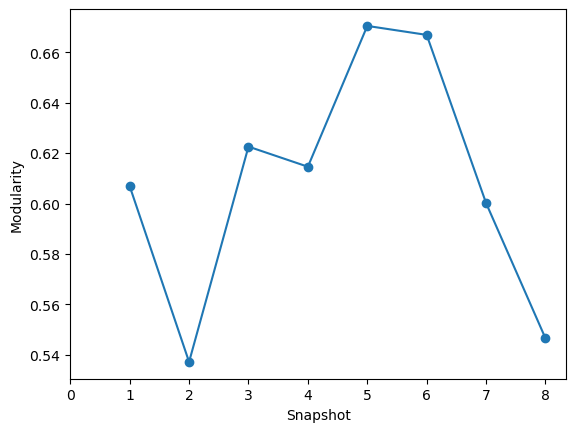

 ==== Number of Communities in each snapshot ====


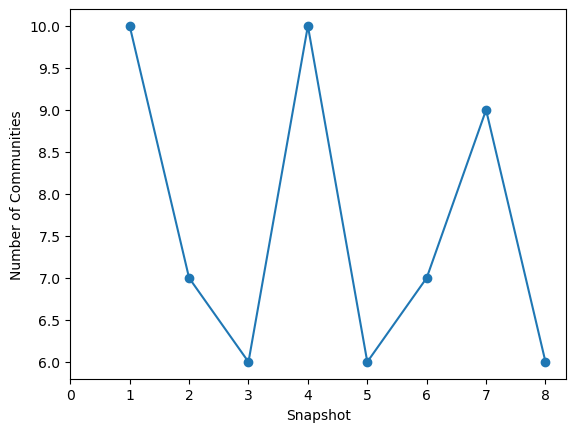

[10, 7, 6, 10, 6, 7, 9, 6]

In [30]:
print(" ==== Modularity scores of the snapshots over time ====")
graphSnapshotsOverTime(modularity, "Modularity")

print(" ==== Number of Communities in each snapshot ====")
graphSnapshotsOverTime(numberOfCommunities, "Number of Communities")

In [31]:
print("Graph 1 is connected : ", nx.is_connected(g1))
print("")
print("Graph 2 is connected : ", nx.is_connected(g2))
print("")
print("Graph 3 is connected : ", nx.is_connected(g3))
print("")
print("Graph 4 is connected : ", nx.is_connected(g4))
print("")
print("Graph 5 is connected : ", nx.is_connected(g5))
print("")
print("Graph 6 is connected : ", nx.is_connected(g6))
print("")
print("Graph 7 is connected : ", nx.is_connected(g7))
print("")
print("Graph 8 is connected : ", nx.is_connected(g8))
print("")

Graph 1 is connected :  True

Graph 2 is connected :  True

Graph 3 is connected :  True

Graph 4 is connected :  True

Graph 5 is connected :  True

Graph 6 is connected :  True

Graph 7 is connected :  True

Graph 8 is connected :  True



## Analysis from snapshot to snpashot

### Snpashot 1 -2

In [32]:
jaccardTable(1,2, communityList1, snap1Cards, communityList2, snap2Cards)

403

In [151]:
17+16+25+23+0+9+7+14+18+21

150

In [33]:
newCardsLanding(snap1Cards,snap2Cards, communityList2, cardsInfo)
# which sets are cards that are not found in the previous snapshot comming from
# this includeds both the base set
# and the commander variant
# Tarkir: Dragonstorm  :  42
# Tarkir: Dragonstorm Commander  :  3
#same logic applied ot subsequent snapshots

162
 ======== Where did New cards end up ======== 
 = There where 162 cards not in the preivous Snapshot = 
 = Community 0 had 34 cards that weren't from the previous snapshot
 = Community 1 had 14 cards that weren't from the previous snapshot
 = Community 2 had 14 cards that weren't from the previous snapshot
 = Community 3 had 16 cards that weren't from the previous snapshot
 = Community 4 had 43 cards that weren't from the previous snapshot
 = Community 5 had 10 cards that weren't from the previous snapshot
 = Community 6 had 31 cards that weren't from the previous snapshot

 == which sets are cards that are not found in the previous snapshot comming from ==

Tarkir: Dragonstorm  :  42
Foundations  :  16
Phyrexia: All Will Be One  :  14
The Lost Caverns of Ixalan  :  10
Bloomburrow  :  10
Duskmourn: House of Horror  :  9
The Brothers' War  :  9
Wilds of Eldraine  :  9
Murders at Karlov Manor  :  9
Outlaws of Thunder Junction  :  7
March of the Machine  :  7
Tarkir: Dragonstorm Comma

0

In [108]:
search2 = [
('Monstrous Rage', 198),
('Emberheart Challenger', 192),
('Heartfire Hero', 187),
('Manifold Mouse', 182),
('Screaming Nemesis', 166),
('Burst Lightning', 155),
('Hired Claw', 146),
('Witchstalker Frenzy', 106),
('Torch the Tower', 96),
('Lightning Strike', 94),
]

searchNewComs(1,2,search2, communityList2)


           Original Community's most important cards

Monstrous Rage
Emberheart Challenger
Heartfire Hero
Manifold Mouse
Screaming Nemesis
Burst Lightning
Hired Claw
Witchstalker Frenzy
Torch the Tower
Lightning Strike

          Going From Snapshot 1 into Snapshot 2


===  com0 ===


===  com1 ===
Monstrous Rage
Burst Lightning
Torch the Tower


===  com2 ===


===  com3 ===
Emberheart Challenger
Heartfire Hero
Manifold Mouse
Screaming Nemesis
Hired Claw
Witchstalker Frenzy
Lightning Strike


===  com4 ===


===  com5 ===


===  com6 ===


All cards survived and appeared in one of the communities


### Snapshot 2 - 3

In [35]:
jaccardTable(2,3, communityList2, snap2Cards, communityList3, snap3Cards)

415

In [152]:
71 + 14 +20 +20+ 41+17+ 56

239

In [36]:
newCardsLanding(snap2Cards,snap3Cards, communityList3, cardsInfo)

37
 ======== Where did New cards end up ======== 
 = There where 37 cards not in the preivous Snapshot = 
 = Community 0 had 11 cards that weren't from the previous snapshot
 = Community 1 had 4 cards that weren't from the previous snapshot
 = Community 2 had 7 cards that weren't from the previous snapshot
 = Community 3 had 7 cards that weren't from the previous snapshot
 = Community 4 had 6 cards that weren't from the previous snapshot
 = Community 5 had 2 cards that weren't from the previous snapshot

 == which sets are cards that are not found in the previous snapshot comming from ==

Final Fantasy  :  15
Duskmourn: House of Horror  :  3
Tarkir: Dragonstorm  :  3
Wilds of Eldraine  :  2
Outlaws of Thunder Junction  :  2
Phyrexia: All Will Be One  :  2
Aetherdrift  :  1
Bloomburrow  :  1
Foundations  :  1
March of the Machine  :  1
Dominaria United  :  1


0

### Snpashot 3 - 4

In [37]:
jaccardTable(3,4, communityList3, snap3Cards, communityList4, snap4Cards)

213

In [153]:
6+2+18+13+6+4

49

In [38]:
newCardsLanding(snap3Cards,snap4Cards, communityList4, cardsInfo)

259
 ======== Where did New cards end up ======== 
 = There where 259 cards not in the preivous Snapshot = 
 = Community 0 had 14 cards that weren't from the previous snapshot
 = Community 1 had 21 cards that weren't from the previous snapshot
 = Community 2 had 53 cards that weren't from the previous snapshot
 = Community 3 had 32 cards that weren't from the previous snapshot
 = Community 4 had 10 cards that weren't from the previous snapshot
 = Community 5 had 9 cards that weren't from the previous snapshot
 = Community 6 had 14 cards that weren't from the previous snapshot
 = Community 7 had 50 cards that weren't from the previous snapshot
 = Community 8 had 40 cards that weren't from the previous snapshot
 = Community 9 had 16 cards that weren't from the previous snapshot

 == which sets are cards that are not found in the previous snapshot comming from ==

Final Fantasy  :  29
Bloomburrow  :  23
Duskmourn: House of Horror  :  23
Foundations  :  22
The Lost Caverns of Ixalan  :  20

0

In [39]:
search3 = [
    ('Monstrous Rage', 0.026628723779765492),
('Burst Lightning', 0.01594578735806465),
('Screaming Nemesis', 0.014769567238329406),
('Emberheart Challenger', 0.013261613491100258),
('Heartfire Hero', 0.013050920615558527),
('Magebane Lizard', 0.012783799983455944),
('Manifold Mouse', 0.012502636991211298),
('Hired Claw', 0.012484470619097562),
('Monastery Swiftspear', 0.00946868268864054),
('Witchstalker Frenzy', 0.009376307588447418)
]
searchNewComs(3,4,search3, communityList4)


           Original Community's most important cards

Monstrous Rage
Burst Lightning
Screaming Nemesis
Emberheart Challenger
Heartfire Hero
Magebane Lizard
Manifold Mouse
Hired Claw
Monastery Swiftspear
Witchstalker Frenzy

          Going From Snapshot 3 into Snapshot 4


===  com0 ===
Burst Lightning
Screaming Nemesis
Emberheart Challenger
Manifold Mouse
Hired Claw
Monastery Swiftspear
Witchstalker Frenzy


===  com1 ===


===  com2 ===


===  com3 ===


===  com4 ===


===  com5 ===


===  com6 ===


===  com7 ===


===  com8 ===


===  com9 ===


 cards that did not appear in snapshot 4
Monstrous Rage
Magebane Lizard
Heartfire Hero



### Snapshot 4 - 5

In [40]:
jaccardTable(4,5, communityList4, snap4Cards, communityList5, snap5Cards)

423

In [154]:
24+20+59+33+8+7+14+46+52+22

285

In [41]:
newCardsLanding(snap4Cards,snap5Cards, communityList5, cardsInfo)

73
 ======== Where did New cards end up ======== 
 = There where 73 cards not in the preivous Snapshot = 
 = Community 0 had 6 cards that weren't from the previous snapshot
 = Community 1 had 1 cards that weren't from the previous snapshot
 = Community 2 had 21 cards that weren't from the previous snapshot
 = Community 3 had 17 cards that weren't from the previous snapshot
 = Community 4 had 9 cards that weren't from the previous snapshot
 = Community 5 had 19 cards that weren't from the previous snapshot

 == which sets are cards that are not found in the previous snapshot comming from ==

Edge of Eternities  :  20
Foundations  :  7
Aetherdrift  :  6
Outlaws of Thunder Junction  :  5
Bloomburrow  :  5
Murders at Karlov Manor  :  5
Wilds of Eldraine  :  5
Tarkir: Dragonstorm  :  4
Duskmourn: House of Horror  :  3
Marvel's Spider-Man  :  3
The Lost Caverns of Ixalan  :  2
Final Fantasy  :  1
Edge of Eternities Commander  :  1


0

### Snapshot 5 -6

In [42]:
jaccardTable(5,6, communityList5, snap5Cards, communityList6, snap6Cards)

211

In [155]:
2+2+8+5+3+7

27

In [43]:
newCardsLanding(snap5Cards,snap6Cards, communityList6 , cardsInfo)

165
 ======== Where did New cards end up ======== 
 = There where 165 cards not in the preivous Snapshot = 
 = Community 0 had 24 cards that weren't from the previous snapshot
 = Community 1 had 40 cards that weren't from the previous snapshot
 = Community 2 had 9 cards that weren't from the previous snapshot
 = Community 3 had 42 cards that weren't from the previous snapshot
 = Community 4 had 11 cards that weren't from the previous snapshot
 = Community 5 had 14 cards that weren't from the previous snapshot
 = Community 6 had 24 cards that weren't from the previous snapshot

 == which sets are cards that are not found in the previous snapshot comming from ==

Final Fantasy  :  20
Bloomburrow  :  16
Marvel's Spider-Man  :  16
The Lost Caverns of Ixalan  :  15
Duskmourn: House of Horror  :  15
Tarkir: Dragonstorm  :  13
Edge of Eternities  :  13
Foundations  :  10
Murders at Karlov Manor  :  8
Outlaws of Thunder Junction  :  8
Wilds of Eldraine  :  7
The Big Score  :  7
Aetherdrift  : 

1

### Snapshot 6 - 7

In [44]:
jaccardTable(6,7, communityList6, snap6Cards, communityList7, snap7Cards)

348

In [156]:
11+18+6+18+13+5+8

79

In [45]:
newCardsLanding(snap6Cards,snap7Cards, communityList7, cardsInfo)

254
 ======== Where did New cards end up ======== 
 = There where 254 cards not in the preivous Snapshot = 
 = Community 0 had 25 cards that weren't from the previous snapshot
 = Community 1 had 32 cards that weren't from the previous snapshot
 = Community 2 had 7 cards that weren't from the previous snapshot
 = Community 3 had 50 cards that weren't from the previous snapshot
 = Community 4 had 14 cards that weren't from the previous snapshot
 = Community 5 had 30 cards that weren't from the previous snapshot
 = Community 6 had 5 cards that weren't from the previous snapshot
 = Community 7 had 52 cards that weren't from the previous snapshot
 = Community 8 had 39 cards that weren't from the previous snapshot

 == which sets are cards that are not found in the previous snapshot comming from ==

Avatar: The Last Airbender  :  60
Tarkir: Dragonstorm  :  19
Wilds of Eldraine  :  18
Bloomburrow  :  18
Foundations  :  17
Duskmourn: House of Horror  :  14
Outlaws of Thunder Junction  :  13
Ae

0

### Snpashot 7 - 8

In [46]:
jaccardTable(7,8, communityList7, snap7Cards, communityList8, snap8Cards)

524

In [157]:
38+27+15+44+12+22+4+35+16

213

In [47]:
newCardsLanding(snap7Cards,snap8Cards, communityList8, cardsInfo)

99
 ======== Where did New cards end up ======== 
 = There where 99 cards not in the preivous Snapshot = 
 = Community 0 had 23 cards that weren't from the previous snapshot
 = Community 1 had 2 cards that weren't from the previous snapshot
 = Community 2 had 14 cards that weren't from the previous snapshot
 = Community 3 had 28 cards that weren't from the previous snapshot
 = Community 4 had 20 cards that weren't from the previous snapshot
 = Community 5 had 12 cards that weren't from the previous snapshot

 == which sets are cards that are not found in the previous snapshot comming from ==

Lorwyn Eclipsed  :  38
Outlaws of Thunder Junction  :  6
Murders at Karlov Manor  :  5
Foundations  :  5
Aetherdrift  :  4
Tarkir: Dragonstorm  :  4
Teenage Mutant Ninja Turtles  :  4
Wilds of Eldraine  :  4
Final Fantasy  :  4
Bloomburrow  :  4
The Lost Caverns of Ixalan  :  3
Duskmourn: House of Horror  :  3
Edge of Eternities  :  3
Marvel's Spider-Man  :  3
Avatar: The Last Airbender  :  2
The 

0

## Reccomendations

In [50]:
tester = ["Imodane's Recruiter", "Voldaren Thrillseeker", 
          "Resolute Reinforcements",'Kaito, Bane of Nightmares',
          'Nowhere to Run', "Draconautics Engineer",
          "Agatha's Soul Cauldron",'Chainsaw',"Warleader's Call" ]
#top10addition(g1, tester)

#"Warleader's Call": 0.00860832137733142,

In [51]:
out = Reccomender(g6, "Reccommender\\Reccommender 1.txt")

  ==== Reccomend Cards based on Edges ====

Kaito, Bane of Nightmares
Preacher of the Schism
Phantom Interference
Tishana's Tidebinder
Stab
Shoot the Sheriff
Deep-Cavern Bat
Essence Scatter
Faebloom Trick
Ouroboroid




## which Cards are in which communities from my decklist

In [52]:
#whichComsIsDeckIn("decklists\\Snapshot 1\\2-16-25\\Standard_Boros_Convoke_by_Masuko_Yuki.txt", communityList1)

## quick search

In [53]:
cardsInfo['Nissa, Worldsoul Speaker']['type_line']

'Legendary Creature — Elf Druid'

In [54]:
cardsInfo['Gohn, Town of Ruin']['type_line']

'Land — Town'

In [55]:
cardsInfo['Treasure Map // Treasure Cove']['type_line']


'Artifact // Land'

In [56]:
search = "Treasure Map"

for c in FullCardList:
    if search.lower() in c["name"].lower():
        print(c["name"])

Treasure Map // Treasure Cove


In [57]:
for x, value in communityList1.items():
    print(x, len(value))

com0 59
com1 54
com2 49
com3 60
com4 11
com5 11
com6 10
com7 40
com8 71
com9 38


### Snapshot 1 label comparison

In [58]:
archOcc1, certDecks1, uncertDecks1, nmi1, ari1, intra1, inter1, tally1   = mainLabelComparisonBody("decklists\\Snapshot 1", communityList1)

### Snapshot 2 label comparison

In [59]:
archOcc2, certDecks2, uncertDecks2, nmi2, ari2, intra2, inter2, tally2   = mainLabelComparisonBody("decklists\\Snapshot 2", communityList2)

### Snapshot 3 label comparison

In [60]:
archOcc3, certDecks3, uncertDecks3, nmi3, ari3, intra3, inter3, tally3   = mainLabelComparisonBody("decklists\\Snapshot 3", communityList3)

### Snapshot 4 label comparison

In [61]:
archOcc4, certDecks4, uncertDecks4, nmi4, ari4, intra4, inter4, tally4   = mainLabelComparisonBody("decklists\\Snapshot 4", communityList4)

### Snapshot 5 label comparison

In [62]:
archOcc5, certDecks5, uncertDecks5, nmi5, ari5, intra5, inter5, tally5   = mainLabelComparisonBody("decklists\\Snapshot 5", communityList5)

### Snapshot 6 label comparison

In [63]:
archOcc6, certDecks6, uncertDecks6, nmi6, ari6, intra6, inter6, tally6   = mainLabelComparisonBody("decklists\\Snapshot 6", communityList6)

### Snapshot 7 label comparison

In [64]:
archOcc7, certDecks7, uncertDecks7, nmi7, ari7, intra7, inter7, tally7   = mainLabelComparisonBody("decklists\\Snapshot 7", communityList7)

### Snapshot 8 label comparison

In [65]:
archOcc8, certDecks8, uncertDecks8, nmi8, ari8, intra8, inter8, tally8   = mainLabelComparisonBody("decklists\\Snapshot 8", communityList8)

In [66]:
print("Number of archetypes     :", len(archOcc1))
print("confidenence split       :",len(certDecks1)/(len(certDecks1)+len(uncertDecks1)))
 
print("NMI score                :" , nmi1)
print("ARI Score                :",ari1)
print("Intra Communiy Similarity:",intra1)
print("Inter Communiy Similarity:",inter1)
#print("# of cards that appear in all decks:",len(tally1))

Number of archetypes     : 63
confidenence split       : 0.9971305595408895
NMI score                : 0.6685151324748083
ARI Score                : 0.4039212419378962
Intra Communiy Similarity: 0.6635623485325891
Inter Communiy Similarity: 0.3142418641140393


In [67]:
print("Number of archetypes     :", len(archOcc2))
print("confidenence split       :",len(certDecks2)/(len(certDecks2)+len(uncertDecks2)))
 
print("NMI score                :" , nmi2)
print("ARI Score                :",ari2)
print("Intra Communiy Similarity:",intra2)
print("Inter Communiy Similarity:",inter2)
#print("# of cards that appear in all decks:",len(tally2))

Number of archetypes     : 59
confidenence split       : 0.9989858012170385
NMI score                : 0.6812570005591552
ARI Score                : 0.5855314149263204
Intra Communiy Similarity: 0.5835173753935899
Inter Communiy Similarity: 0.3093847471799096


In [68]:
print("Number of archetypes     :", len(archOcc3))
print("confidenence split       :",len(certDecks3)/(len(certDecks3)+len(uncertDecks3)))
 
print("NMI score                :" , nmi3)
print("ARI Score                :",ari3)
print("Intra Communiy Similarity:",intra3)
print("Inter Communiy Similarity:",inter3)

Number of archetypes     : 23
confidenence split       : 1.0
NMI score                : 0.8023791565281578
ARI Score                : 0.7731265498076405
Intra Communiy Similarity: 0.6296646493713782
Inter Communiy Similarity: 0.27845948792999636


In [69]:
print("Number of archetypes     :", len(archOcc4))
print("confidenence split       :",len(certDecks4)/(len(certDecks4)+len(uncertDecks4)))
 
print("NMI score                :" , nmi4)
print("ARI Score                :",ari4)
print("Intra Communiy Similarity:",intra4)
print("Inter Communiy Similarity:",inter4)

Number of archetypes     : 52
confidenence split       : 1.0
NMI score                : 0.6991181343319262
ARI Score                : 0.5492747780050007
Intra Communiy Similarity: 0.6889267086184331
Inter Communiy Similarity: 0.31580897147984416


In [70]:
print("Number of archetypes     :", len(archOcc5))
print("confidenence split       :",len(certDecks5)/(len(certDecks5)+len(uncertDecks5)))
 
print("NMI score                :" , nmi5)
print("ARI Score                :",ari5)
print("Intra Communiy Similarity:",intra5)
print("Inter Communiy Similarity:",inter5)

Number of archetypes     : 27
confidenence split       : 1.0
NMI score                : 0.771256595859138
ARI Score                : 0.6608694843258279
Intra Communiy Similarity: 0.6157442915679402
Inter Communiy Similarity: 0.2674459010940503


In [71]:
print("Number of archetypes     :", len(archOcc6))
print("confidenence split       :",len(certDecks6)/(len(certDecks6)+len(uncertDecks6)))
 
print("NMI score                :" , nmi6)
print("ARI Score                :",ari6)
print("Intra Communiy Similarity:",intra6)
print("Inter Communiy Similarity:",inter6)

Number of archetypes     : 45
confidenence split       : 0.996309963099631
NMI score                : 0.7779176049248314
ARI Score                : 0.7174829809015469
Intra Communiy Similarity: 0.6718810994513355
Inter Communiy Similarity: 0.2850409256699903


In [72]:
print("Number of archetypes     :", len(archOcc7))
print("confidenence split       :",len(certDecks7)/(len(certDecks7)+len(uncertDecks7)))
 
print("NMI score                :" , nmi7)
print("ARI Score                :",ari7)
print("Intra Communiy Similarity:",intra7)
print("Inter Communiy Similarity:",inter7)

Number of archetypes     : 80
confidenence split       : 0.9865016872890888
NMI score                : 0.6619579918063407
ARI Score                : 0.33523251133690773
Intra Communiy Similarity: 0.5948651628072625
Inter Communiy Similarity: 0.29968018525003637


In [73]:
print("Number of archetypes     :", len(archOcc8))
print("confidenence split       :",len(certDecks8)/(len(certDecks8)+len(uncertDecks8)))
 
print("NMI score                :" , nmi8)
print("ARI Score                :",ari8)
print("Intra Communiy Similarity:",intra8)
print("Inter Communiy Similarity:",inter8)

Number of archetypes     : 77
confidenence split       : 0.9896755162241888
NMI score                : 0.6517231862626683
ARI Score                : 0.37376563911213606
Intra Communiy Similarity: 0.5563943613468477
Inter Communiy Similarity: 0.32225242203955173


In [74]:
temp = [communityList1,communityList2,communityList3,communityList4,communityList5,communityList6,communityList7,communityList8]
testoutput = []
for x in temp:
    print(len(x))
    for key,y in x.items():
        #print(y)
        testoutput.append(len(y))
    

10
7
6
10
6
7
9
6


### Measureing diversity

In [105]:
#
# 10 communities is nice but if 90 of the 100 decks are all from 1 community its not as diverse
#
def diversity(decksList):
    comCounts = {}
    for key,value in decksList.items():
        #print(value["MainCom"])
        if value["MainCom"] in comCounts:
            comCounts[value["MainCom"]] = comCounts[value["MainCom"]] +1
        else:
            comCounts[value["MainCom"]] = 1

    total = 0
    for key,value in comCounts.items():
        total += value

    forShannon = []
    for x in sorted(comCounts):
        print(x ,"  ",comCounts[x] ," ", comCounts[x] / total)
        temp = comCounts[x]/ total
        forShannon.append(temp*math.log(temp))


    
    shannonValue = -(sum(forShannon))
    normShanVal = shannonValue/math.log(len(sorted(comCounts)))
    return comCounts, total, normShanVal


shannonOverTime = []
temp = certDecks1.copy()
temp.update(uncertDecks1)
ot, ot2, ot3 = diversity(temp)
print(ot2)
print(ot3)
shannonOverTime.append(ot3)

com0    194   0.2783357245337159
com1    34   0.04878048780487805
com2    27   0.03873744619799139
com3    130   0.18651362984218078
com4    39   0.05595408895265423
com5    7   0.010043041606886656
com6    1   0.0014347202295552368
com7    139   0.1994261119081779
com8    116   0.16642754662840745
com9    10   0.014347202295552367
697
0.7992059973837239


In [94]:
temp = certDecks2.copy()
temp.update(uncertDecks2)
ot, ot2, ot3 = diversity(temp)
print(ot2)
print(ot3)
shannonOverTime.append(ot3)

com0    102   0.10344827586206896
com1    325   0.32961460446247465
com2    7   0.007099391480730223
com3    113   0.11460446247464504
com4    188   0.19066937119675456
com5    8   0.008113590263691683
com6    243   0.24645030425963488
986
0.814074394612649


In [95]:
temp = certDecks3.copy()
temp.update(uncertDecks3)
ot, ot2, ot3 = diversity(temp)
print(ot2)
print(ot3)
shannonOverTime.append(ot3)

com0    5   0.023809523809523808
com1    27   0.12857142857142856
com2    29   0.1380952380952381
com3    75   0.35714285714285715
com4    7   0.03333333333333333
com5    67   0.319047619047619
210
0.8213762789534418


In [97]:
temp = certDecks4.copy()
temp.update(uncertDecks4)
ot, ot2, ot3 = diversity(temp)
print(ot2)
print(ot3)
shannonOverTime.append(ot3)

com0    19   0.05846153846153846
com1    12   0.036923076923076927
com2    47   0.14461538461538462
com3    98   0.30153846153846153
com4    1   0.003076923076923077
com5    1   0.003076923076923077
com6    1   0.003076923076923077
com7    8   0.024615384615384615
com8    115   0.35384615384615387
com9    23   0.07076923076923076
325
0.707268099820339


In [98]:
temp = certDecks5.copy()
temp.update(uncertDecks5)
ot, ot2, ot3 = diversity(temp)
print(ot2)
print(ot3)
shannonOverTime.append(ot3)

com0    25   0.1358695652173913
com1    55   0.29891304347826086
com2    22   0.11956521739130435
com3    30   0.16304347826086957
com4    2   0.010869565217391304
com5    50   0.2717391304347826
184
0.8846255398160268


In [99]:
temp = certDecks6.copy()
temp.update(uncertDecks6)
ot, ot2, ot3 = diversity(temp)
print(ot2)
print(ot3)
shannonOverTime.append(ot3)

com0    82   0.15129151291512916
com1    32   0.05904059040590406
com2    170   0.31365313653136534
com3    87   0.16051660516605165
com5    126   0.23247232472324722
com6    35   0.06457564575645756
com7    10   0.01845018450184502
542
0.8735564040382872


In [100]:
temp = certDecks7.copy()
temp.update(uncertDecks7)
ot, ot2, ot3 = diversity(temp)
print(ot2)
print(ot3)
shannonOverTime.append(ot3)

com0    90   0.10123734533183353
com1    44   0.049493813273340834
com2    18   0.020247469066366704
com3    231   0.25984251968503935
com4    49   0.05511811023622047
com5    117   0.13160854893138357
com6    1   0.0011248593925759281
com7    88   0.09898762654668167
com8    251   0.2823397075365579
889
0.8328925304275429


In [101]:
temp = certDecks8.copy()
temp.update(uncertDecks8)
ot, ot2, ot3 = diversity(temp)
print(ot2)
print(ot3)
shannonOverTime.append(ot3)

com0    180   0.26548672566371684
com1    91   0.13421828908554573
com2    102   0.1504424778761062
com3    58   0.0855457227138643
com4    137   0.20206489675516223
com5    110   0.16224188790560473
678
0.9683945937912044


In [84]:
print(len(certDecks1))
print(len(uncertDecks1))
print(len(temp))

695
2
678


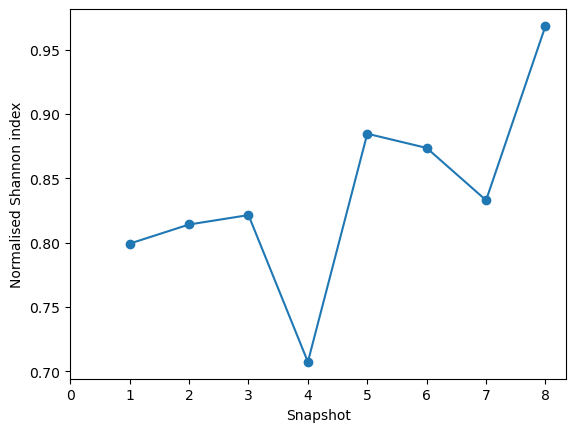

[0.7992059973837239,
 0.814074394612649,
 0.8213762789534418,
 0.707268099820339,
 0.8846255398160268,
 0.8735564040382872,
 0.8328925304275429,
 0.9683945937912044]

In [102]:
graphSnapshotsOverTime(shannonOverTime, "Normalised Shannon index")

### Shannon index

## Graphing banned cards

In [181]:
def graphOverTime(CardList, stats, y_label):

    for y in CardList:
        temp = []
        for x in stats:
            if y in x:
                temp.append(x[y])

            else:
                temp.append(None)

        plt.plot(range(1,len(temp)+1), temp, marker="o", label=y)
        plt.xticks(range(len(temp)+1))
    plt.xlabel("Snapshot")
    plt.ylabel(y_label)
    plt.legend(fontsize=8)
    plt.savefig(f"{y_label}.png", dpi=300, bbox_inches="tight")
    plt.show()
    return 0

In [183]:
def graphOverTimeComparison(CardList, stats, y_label, colours):

    for key,y in enumerate(CardList):
        temp = []
        for x in stats:
            if y in x:
                temp.append(x[y])

            else:
                temp.append(None)

        plt.plot(range(1,len(temp)+1), temp, marker="o", label=y, color=colours[key])
        plt.xticks(range(len(temp)+1))
    plt.xlabel("Snapshot")
    plt.ylabel(y_label)
    #plt.legend(fontsize=8)
    plt.savefig(f"{y_label}.png", dpi=300, bbox_inches="tight")
    plt.show()
    return 0

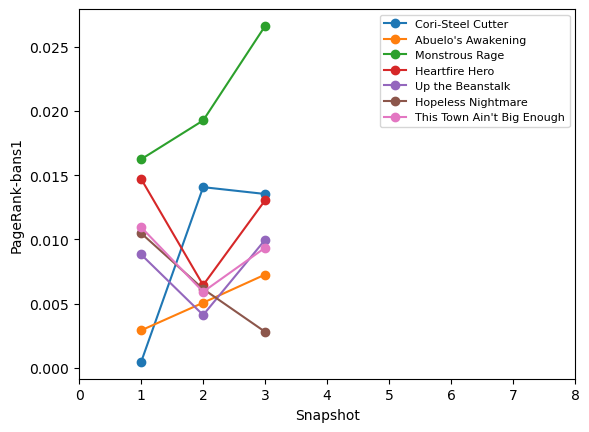

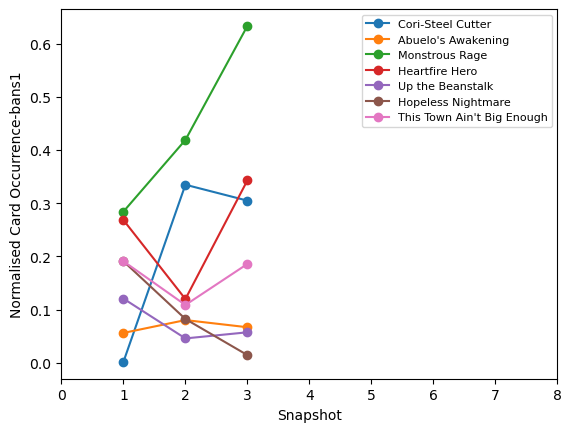

0

In [182]:
#Dragonhawk, Fate's Tempest 

## FIRST BANS 
## "Cori-Steel Cutter"
## "Abuelo's Awakening"
# "Monstrous Rage"
# "Heartfire Hero"
# "Up the Beanstalk"
# "Hopeless Nightmare"
# "This Town Ain't Big Enough"
#
# SECCOND BANS
# "Vivi Ornitier"
# "Proft's Eidetic Memory"
# "Screaming Nemesis"
#
# tester ===== > "Agatha's Soul Cauldron"
#
bans1 = ("Cori-Steel Cutter","Abuelo's Awakening","Monstrous Rage","Heartfire Hero","Up the Beanstalk","Hopeless Nightmare","This Town Ain't Big Enough")
graphOverTime(bans1, pageranks,"PageRank-bans1")
graphOverTime(bans1, cardOccurancesNorm,"Normalised Card Occurrence-bans1")

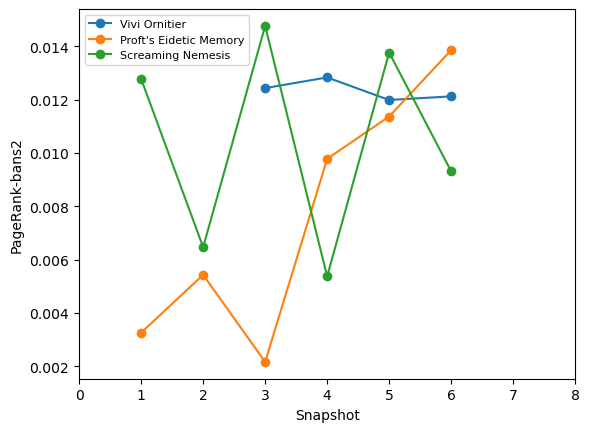

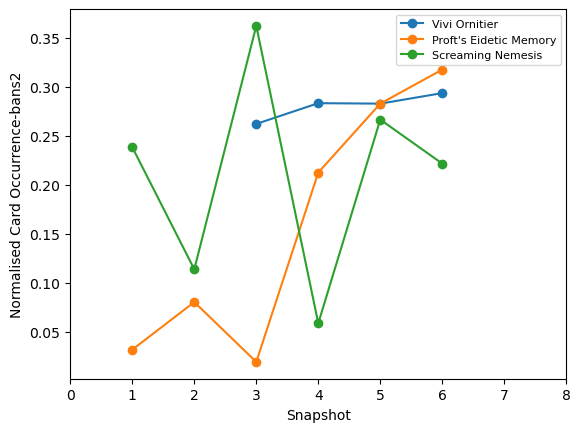

0

In [171]:
bans2 = ("Vivi Ornitier","Proft's Eidetic Memory", "Screaming Nemesis")
graphOverTime(bans2, pageranks,"PageRank-bans2")
graphOverTime(bans2, cardOccurancesNorm,"Normalised Card Occurrence-bans2")

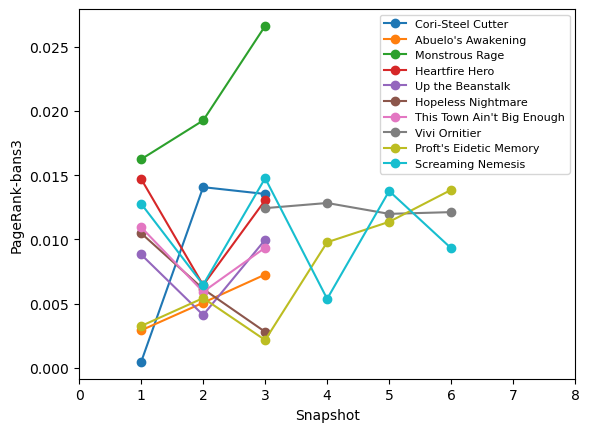

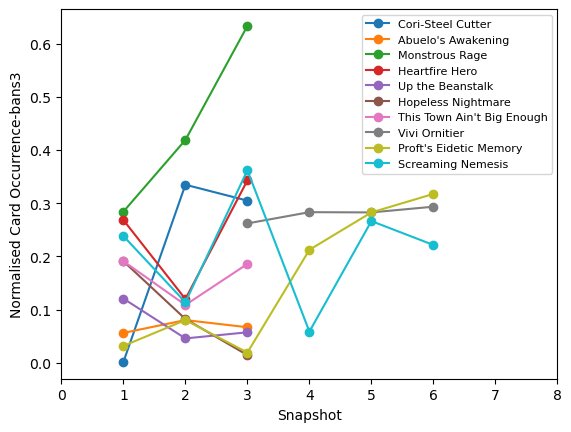

0

In [172]:
bans3 = ("Cori-Steel Cutter","Abuelo's Awakening","Monstrous Rage","Heartfire Hero","Up the Beanstalk","Hopeless Nightmare","This Town Ain't Big Enough","Vivi Ornitier","Proft's Eidetic Memory", "Screaming Nemesis")
graphOverTime(bans3, pageranks,"PageRank-bans3")
graphOverTime(bans3, cardOccurancesNorm,"Normalised Card Occurrence-bans3")

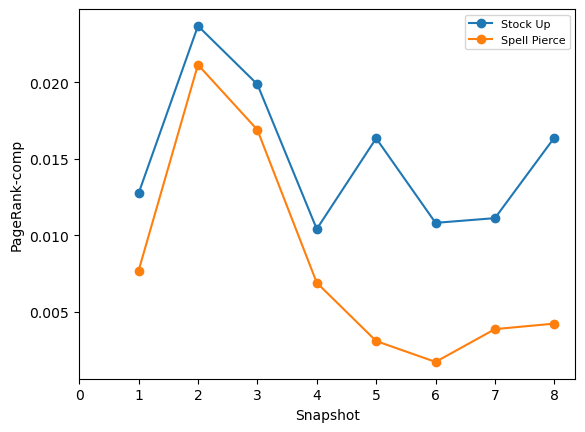

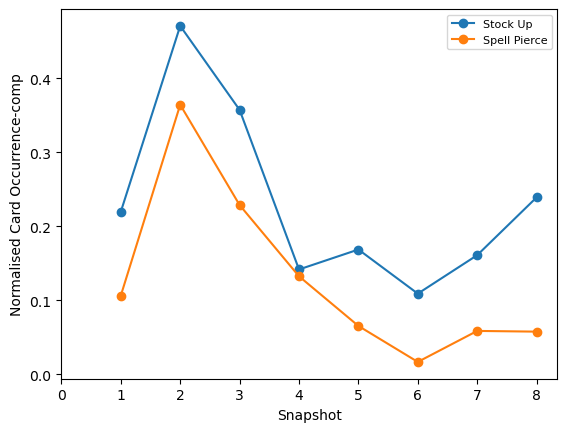

0

In [173]:
comparisons = ('Stock Up', "Spell Pierce")
graphOverTime(comparisons, pageranks,"PageRank-comp")
graphOverTime(comparisons, cardOccurancesNorm,"Normalised Card Occurrence-comp")

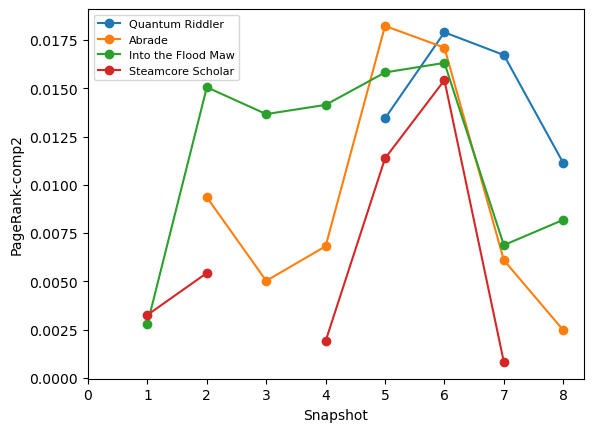

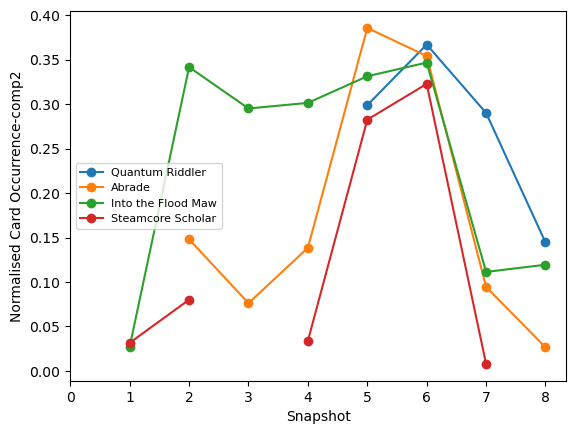

0

In [174]:
comparisons2 = ('Quantum Riddler','Abrade','Into the Flood Maw','Steamcore Scholar')

graphOverTime(comparisons2, pageranks,"PageRank-comp2")
graphOverTime(comparisons2, cardOccurancesNorm,"Normalised Card Occurrence-comp2")

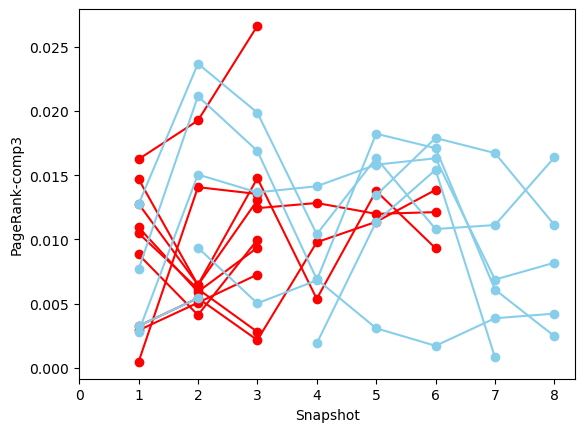

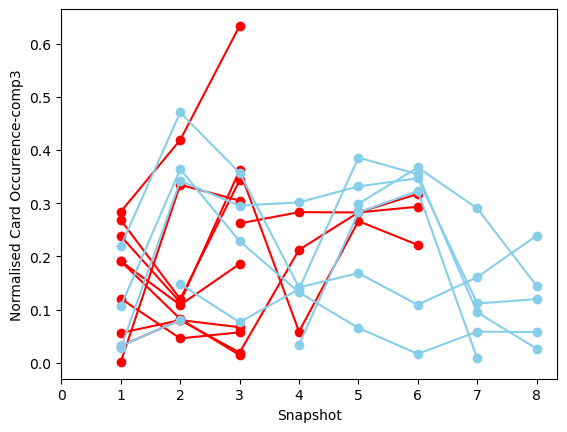

0

In [185]:
c1 = ("Cori-Steel Cutter","Abuelo's Awakening","Monstrous Rage","Heartfire Hero","Up the Beanstalk","Hopeless Nightmare","This Town Ain't Big Enough","Vivi Ornitier","Proft's Eidetic Memory", "Screaming Nemesis",'Stock Up', "Spell Pierce",'Quantum Riddler','Abrade','Into the Flood Maw','Steamcore Scholar')
col = ("red",               "red",                "red",           "red",                "red",           "red",                "red",                    "red",             "red",                   "red",        "Skyblue",   "Skyblue",       "Skyblue",         "Skyblue",    "Skyblue",      "Skyblue",       )
graphOverTimeComparison(c1, pageranks,"PageRank-comp3",col)
graphOverTimeComparison(c1, cardOccurancesNorm,"Normalised Card Occurrence-comp3",col)